#### Model Performance Metrics

Creates table of model performance metrics use for each watershed and water use type (e.g. public supply, irrigation) for the calibration run. NB: these metrics for US side of watershed only as validation data only covers US side. 
\
\
Currently missing modeled thermoelectric data.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# get filepath 
cd = Path.cwd() 

# create folder to store clean data 
out_dir = Path(f"{cd}/Figures")
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
##### ---------- MANUAL SET UP ----------

# for each calibration scenario you want included in the figure, set scenario name, run date

scenarios = [
    {
        'scenario': 'calibration',
        'run_dates': {
            'GBSJ': '2026-07-16',
            'LCRR': '2026-07-16',
            'MILK': '2026-07-16',
        }
    }
]

In [3]:
##### ---------- PREP DATA ----------

def prep_data(watershed, scenarios):

    ### ----- PREP USGS VALIDATION DATA -----
    USGS_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/USGS_validation.csv")
    USGS_data.loc[USGS_data["Watershed"] == "GBSJ", "in_us"] = 1
    USGS_data = USGS_data[USGS_data["in_us"] != 0]

    data_for_fig = USGS_data

    ### ----- LOOP OVER SCENARIOS, MERGE EACH ONE IN -----
    all_regions = pd.read_csv('/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/HUC12/US_region_list.csv')
    all_regions = all_regions.rename(columns={'huc12': 'HUC12'})

    for s in scenarios:
        scenario = s['scenario']
        run_date = s['run_dates'][watershed]

        # load data
        model_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/{scenario}-{run_date}.csv")

        # filter out non-US HUCs
        model_data = model_data.merge(all_regions, on='HUC12', how='left')
        model_data.loc[model_data["Watershed"] == "GBSJ", "in_us"] = 1
        model_data = model_data[model_data["in_us"] != 0]

        # merge this scenario's columns into the growing data_for_fig
        data_for_fig = data_for_fig.merge(model_data, on=['Year', 'Watershed', 'HUC12', 'in_us'], how='outer')

    return data_for_fig

### ----- RUN FOR EACH WATERSHED -----

watersheds = ['GBSJ', 'LCRR', 'MILK']
data_for_fig = {w: prep_data(w, scenarios) for w in watersheds}

In [4]:
##### ---------- DEFINE METRIC FUNCTIONS ----------

def nse(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    denom = np.sum((obs - obs.mean()) ** 2)
    if denom == 0:
        return np.nan
    return 1 - np.sum((obs - sim) ** 2) / denom


def kge(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    if obs.std() == 0 or obs.mean() == 0:
        return np.nan, np.nan, np.nan, np.nan
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = sim.std() / obs.std()
    beta = sim.mean() / obs.mean()
    kge_val = 1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)
    return kge_val, r, alpha, beta


def pbias(obs, sim):
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    if np.sum(obs) == 0:
        return np.nan
    return 100 * np.sum(sim - obs) / np.sum(obs)


def compute_all_metrics(obs, sim):
    nse_val = nse(obs, sim)
    kge_val, r, alpha, beta = kge(obs, sim)
    pbias_val = pbias(obs, sim)
    return {
        "NSE": nse_val,
        "KGE": kge_val,
        "KGE_r": r,
        "KGE_alpha": alpha,
        "KGE_beta": beta,
        "PBIAS_%": pbias_val,
    }

In [5]:
##### ---------- COMPUTE METRICS ----------

def compute_ensemble_metrics(df, watershed):

    variables = {
        "public_supply": ("public_supply_mil_gal_validation", "public_supply_mil_gal_calibration"),
        "irrigation": ("irrigation_mil_gal_validation", "irrigation_mil_gal_calibration"),
    }

    periods = {
        "calibration_period": (2000, 2015),
        "validation_period": (2016, 2020),
    }

    metric_cols = ["NSE", "KGE", "KGE_r", "KGE_alpha", "KGE_beta", "PBIAS_%"]

    # ---- Step 1: per run x period x variable ----
    per_run_results = []

    for period_name, (y_start, y_end) in periods.items():
        period_df = df[(df["Year"] >= y_start) & (df["Year"] <= y_end)]

        for var_name, (obs_col, sim_col) in variables.items():
            grouped = period_df.groupby("run_ID")
            for run_id, grp in grouped:
                obs = grp[obs_col].values
                sim = grp[sim_col].values

                mask = ~np.isnan(obs) & ~np.isnan(sim)
                obs = obs[mask]
                sim = sim[mask]

                if len(obs) == 0:
                    continue

                metrics = compute_all_metrics(obs, sim)
                metrics.update({
                    "run_ID": run_id,
                    "variable": var_name,
                    "period": period_name,
                })
                per_run_results.append(metrics)

    per_run_df = pd.DataFrame(per_run_results)
    col_order = ["run_ID", "variable", "period"] + metric_cols
    per_run_df = per_run_df[col_order]
    per_run_df.insert(0, "watershed", watershed)

    # ---- Step 2: average (and std) across run_ID for ensemble summary ----
    summary_df = (
        per_run_df
        .groupby(["variable", "period"])[metric_cols]
        .agg(["mean", "std"])
        .round(3)
    )
    summary_df["watershed"] = watershed
    summary_df = summary_df.set_index("watershed", append=True)

    return per_run_df, summary_df


### ----- LOOP THROUGH ALL WATERSHEDS -----

all_per_run = []
all_summary = []

for watershed in watersheds:
    df_ws = data_for_fig[watershed]
    per_run_df, summary_df = compute_ensemble_metrics(df_ws, watershed)
    all_per_run.append(per_run_df)
    all_summary.append(summary_df)

per_run_df_all = pd.concat(all_per_run, ignore_index=True)
summary_df_all = pd.concat(all_summary)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", None)

print("\n=== Ensemble summary (mean ± std across 50 runs), all watersheds ===")
print(summary_df_all)


=== Ensemble summary (mean ± std across 50 runs), all watersheds ===
                                              NSE           KGE         KGE_r        KGE_alpha        KGE_beta        PBIAS_%       
                                             mean    std   mean    std   mean    std      mean    std     mean    std    mean    std
variable      period             watershed                                                                                          
irrigation    calibration_period GBSJ       0.514  0.000  0.746  0.001  0.760  0.000     1.010  0.000    1.081  0.002   8.118  0.153
              validation_period  GBSJ       0.082  0.001  0.231  0.002  0.734  0.000     1.392  0.000    1.606  0.003  60.588  0.251
public_supply calibration_period GBSJ       0.865  0.000  0.884  0.000  0.940  0.000     1.075  0.000    1.066  0.000   6.570  0.028
              validation_period  GBSJ       0.910  0.000  0.838  0.000  0.964  0.000     1.091  0.000    1.129  0.000  12.916  0.019

In [6]:
##### ---------- BUILD PUBLICATION TABLE ----------

def format_summary_table_wide(summary_df_all, metric_cols):
    rows = []
    for (variable, period, watershed), row in summary_df_all.iterrows():
        entry = {
            "Watershed": watershed,
            "Variable": variable.replace("_", " ").title(),
            "Period": period.replace("_period", "").title(),
        }
        for metric in metric_cols:
            mean_val = row[(metric, "mean")]
            std_val = row[(metric, "std")]
            entry[metric] = "–" if pd.isna(mean_val) else f"{mean_val:.2f} ± {std_val:.2f}"
        rows.append(entry)

    long_df = pd.DataFrame(rows)

    # pivot: index = Watershed, Variable | columns = Period, Metric
    wide_df = long_df.pivot(index=["Watershed", "Variable"], columns="Period", values=metric_cols)

    # reorder so Calibration block comes before Validation block
    wide_df = wide_df.reorder_levels([1, 0], axis=1)
    wide_df = wide_df[["Calibration", "Validation"]]

    # sort rows
    wide_df = wide_df.reset_index()
    wide_df["Watershed"] = pd.Categorical(wide_df["Watershed"], categories=["GBSJ", "LCRR", "MILK"], ordered=True)
    wide_df["Variable"] = pd.Categorical(wide_df["Variable"], categories=["Public Supply", "Irrigation"], ordered=True)
    wide_df = wide_df.sort_values(["Watershed", "Variable"]).reset_index(drop=True)

    return wide_df


metric_cols = ["NSE", "KGE", "PBIAS_%"]  
table_df = format_summary_table_wide(summary_df_all, metric_cols)

print(table_df)

Period Watershed       Variable   Calibration                               Validation                            
                                          NSE          KGE       PBIAS_%           NSE          KGE        PBIAS_%
0           GBSJ  Public Supply   0.86 ± 0.00  0.88 ± 0.00   6.57 ± 0.03   0.91 ± 0.00  0.84 ± 0.00   12.92 ± 0.02
1           GBSJ     Irrigation   0.51 ± 0.00  0.75 ± 0.00   8.12 ± 0.15   0.08 ± 0.00  0.23 ± 0.00   60.59 ± 0.25
2           LCRR  Public Supply   0.84 ± 0.00  0.80 ± 0.00   8.56 ± 0.15   0.85 ± 0.00  0.76 ± 0.00   12.54 ± 0.20
3           LCRR     Irrigation  -0.25 ± 0.04  0.39 ± 0.02  29.30 ± 2.28   0.04 ± 0.02  0.52 ± 0.03  -16.22 ± 7.35
4           MILK  Public Supply   0.92 ± 0.00  0.95 ± 0.00  -2.15 ± 0.25   0.92 ± 0.00  0.95 ± 0.00    2.08 ± 0.43
5           MILK     Irrigation  -0.12 ± 0.20  0.50 ± 0.07  -4.99 ± 3.61  -0.16 ± 0.21  0.46 ± 0.10   17.68 ± 4.08


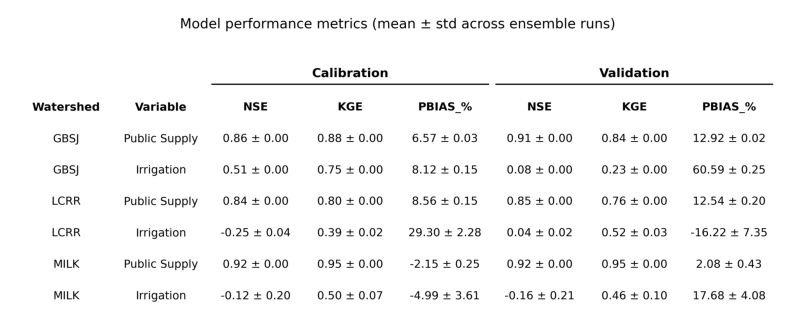

In [7]:
##### ---------- RENDER AS PNG (side-by-side calibration / validation) ----------

def render_table_image_grouped(table_df, out_path, title=None):
    # table_df has MultiIndex columns: (Period, Metric) for metric cols,
    # and flat ("Watershed", ""), ("Variable", "") for label cols
    label_cols = [("Watershed", ""), ("Variable", "")]
    metric_col_pairs = [c for c in table_df.columns if c not in label_cols]

    periods = list(dict.fromkeys([c[0] for c in metric_col_pairs]))  # ["Calibration", "Validation"]
    metrics_per_period = [c[1] for c in metric_col_pairs if c[0] == periods[0]]

    n_rows = len(table_df)
    n_label_cols = len(label_cols)
    n_metric_cols = len(metric_col_pairs)
    n_cols = n_label_cols + n_metric_cols

    fig_width = 1.1 * n_cols
    fig_height = 0.4 * (n_rows + 3)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    # build header rows: row 0 = period group labels, row 1 = metric labels
    group_header = []
    metric_header = []
    for col in label_cols:
        group_header.append("")
        metric_header.append(col[0])
    for col in metric_col_pairs:
        group_header.append(col[0])
        metric_header.append(col[1])

    cell_text = table_df.values.tolist()

    tbl = ax.table(
        cellText=cell_text,
        colLabels=metric_header,
        loc="center",
        cellLoc="center",
        bbox=[0, 0, 1, 0.85],  # leave room above for group header row
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)

    # style: no vertical gridlines, horizontal rules only, sans-serif font
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("none")
        cell.set_text_props(fontfamily="sans-serif")
        if row == 0:
            cell.set_text_props(weight="bold", fontfamily="sans-serif")
            cell.visible_edges = "B"
            cell.set_linewidth(1.0)
        elif row == n_rows:
            cell.visible_edges = "B"
            cell.set_linewidth(1.2)

    # add group header row (Calibration | Validation) manually above the table
    start = n_label_cols
    for period in periods:
        span = len(metrics_per_period)
        col_idx = start
        ax.text(
            (col_idx + span / 2) / n_cols,
            0.92,
            period,
            ha="center", va="center",
            fontsize=10, fontweight="bold", fontfamily="sans-serif",
            transform=ax.transAxes,
        )
        # underline the group
        ax.plot(
            [col_idx / n_cols + 0.005, (col_idx + span) / n_cols - 0.005],
            [0.88, 0.88],
            color="black", linewidth=1.0,
            transform=ax.transAxes,
        )
        start += span

    if title:
        ax.set_title(title, fontsize=11, fontfamily="sans-serif", pad=20)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

render_table_image_grouped(
    table_df,
    out_path=f"{out_dir}/model_performance_table.png",
    title="Model performance metrics (mean ± std across ensemble runs)"
)

img = mpimg.imread(f"{out_dir}/model_performance_table.png")
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(img)
ax.axis("off")
plt.show()